In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
# ファイルの読み込み
import numpy as np

def read_data(filename):
    labels, sentences = [], []
    with open(filename) as f:
        for line in f:
            t = int(line[0])
            # labels.append([[0, t],[0, 1-t]]) # 2×2行列の形で格納するならこっち
            labels.append([1-t, t]) # 1×2行列の形
            sentences.append(line[1:].strip())
            
    return np.array(labels), sentences

train_labels, train_sentences = read_data('datasets/mc_train_data_jp.txt')
dev_labels, dev_sentences = read_data('datasets/mc_dev_data_jp.txt')
test_labels, test_sentences = read_data('datasets/mc_test_data_jp.txt')

In [3]:
# 文のトークン化
import spacy

def tokenise(sentence):
    nlp = spacy.load("ja_core_news_sm")
    doc = nlp(sentence)
    tokens = [token.text for token in doc]
    return tokens

train_tokenised = [tokenise(sentence) for sentence in train_sentences]
dev_tokenised = [tokenise(sentence) for sentence in dev_sentences]
test_tokenised = [tokenise(sentence) for sentence in test_sentences]

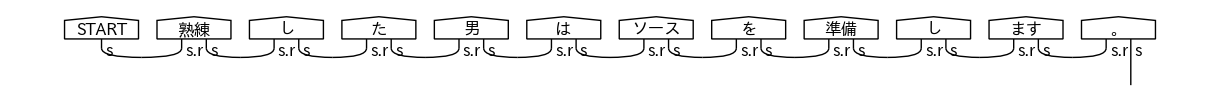

In [115]:
# diagram作成（removecupsなしの場合）
from lambeq import cups_reader, spiders_reader
import japanize_matplotlib

train_diagrams=[]
dev_diagrams=[]
test_diagrams=[]

for i in range(len(train_tokenised)):
    train_diagrams.append(cups_reader.sentence2diagram(train_tokenised[i], tokenised=True))
for i in range(len(dev_tokenised)):
    dev_diagrams.append(cups_reader.sentence2diagram(dev_tokenised[i], tokenised=True))
for i in range(len(test_tokenised)):
    test_diagrams.append(cups_reader.sentence2diagram(test_tokenised[i], tokenised=True))

train_diagrams[0].draw(figsize=(12,2), fontsize=12)

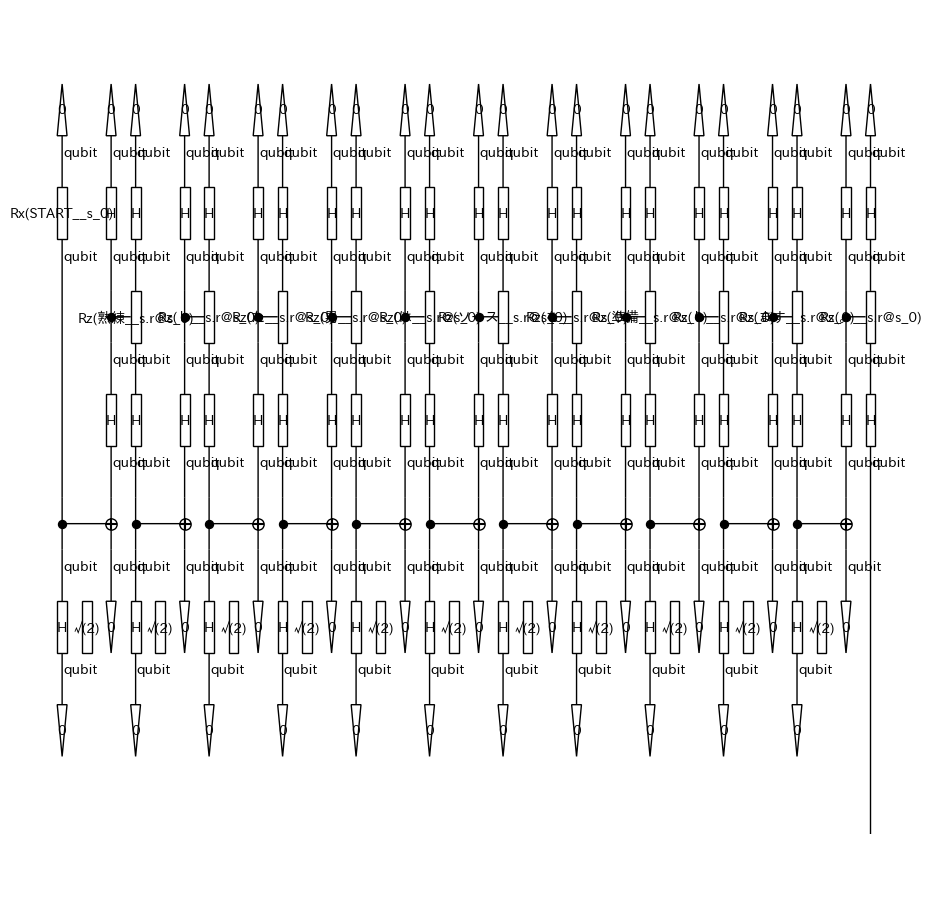

In [149]:
# 量子回路設計（IQPAnsatz）
from lambeq import AtomicType, IQPAnsatz

ansatz = IQPAnsatz({AtomicType.NOUN: 1, AtomicType.SENTENCE: 1},
                   n_layers=1, n_single_qubit_params=1)

train_circuits = [ansatz(diagram) for diagram in train_diagrams]
dev_circuits =  [ansatz(diagram) for diagram in dev_diagrams]
test_circuits = [ansatz(diagram) for diagram in test_diagrams]

train_circuits[0].draw(figsize=(9, 9))

In [150]:
# 量子回路シミュレーションをする計算モデルを構築
from lambeq import NumpyModel

all_circuits = train_circuits + dev_circuits + test_circuits # モデル初期化時に全量子回路を提供するための準備
model = NumpyModel.from_diagrams(all_circuits, use_jit=True)

In [151]:
# 損失関数と予測精度の定義
from lambeq import BinaryCrossEntropyLoss

bce = BinaryCrossEntropyLoss(use_jax=True)
acc = lambda y_hat, y: np.sum(np.round(y_hat) == y) / len(y) / 2
# roundで四捨五入して0or1に変換  # 正解数を総数で割る

In [152]:
# ハイパーパラメータ
BATCH_SIZE = 30
# LEARNING_RATE = 3e-2
EPOCHS = 400
SEED = 0

In [153]:
# trainerの定義
from lambeq import QuantumTrainer, SPSAOptimizer

trainer = QuantumTrainer(
    model,
    loss_function=bce,
    epochs=EPOCHS,
    optimizer=SPSAOptimizer,
    optim_hyperparams={'a': 0.1, 'c': 0.06, 'A':0.01*EPOCHS},
    evaluate_functions={'acc': acc},
    evaluate_on_train=True,
    verbose='text',
    seed=SEED
)

In [154]:
from lambeq import Dataset

train_dataset = Dataset(train_circuits, train_labels, batch_size=BATCH_SIZE)
val_dataset = Dataset(dev_circuits, dev_labels, shuffle=False)

In [155]:
trainer.fit(train_dataset, val_dataset, log_interval=100)

Epoch 100:  train/loss: 0.6185   valid/loss: 0.5923   train/time: 24.40s   valid/time: 8.70s   train/acc: 0.7541   valid/acc: 0.8000
Epoch 200:  train/loss: 0.5617   valid/loss: 0.5543   train/time: 11.00s   valid/time: 2.65s   train/acc: 0.7869   valid/acc: 0.8000
Epoch 300:  train/loss: 1.1337   valid/loss: 0.4895   train/time: 11.10s   valid/time: 2.66s   train/acc: 0.8033   valid/acc: 0.8000
Epoch 400:  train/loss: 0.3611   valid/loss: 0.4876   train/time: 11.04s   valid/time: 2.66s   train/acc: 0.8033   valid/acc: 0.8000

Training completed!
train/time: 57.53s   train/time_per_epoch: 0.14s   train/time_per_step: 0.05s   valid/time: 16.66s   valid/time_per_eval: 0.04s


Train accuracy: 0.8032787
Test accuracy: 0.73333335


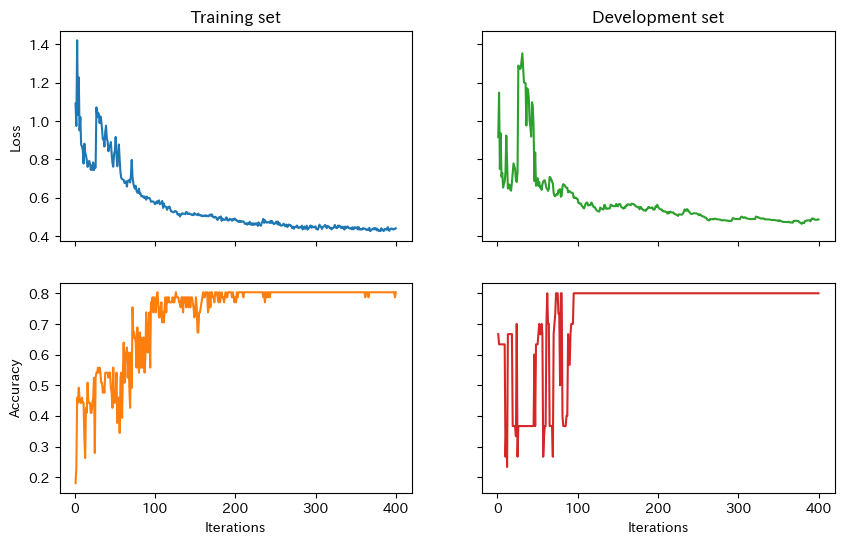

In [156]:
import matplotlib.pyplot as plt
import numpy as np

fig, ((ax_tl, ax_tr), (ax_bl, ax_br)) = plt.subplots(2, 2, sharex=True, sharey='row', figsize=(10, 6))
ax_tl.set_title('Training set')
ax_tr.set_title('Development set')
ax_bl.set_xlabel('Iterations')
ax_br.set_xlabel('Iterations')
ax_bl.set_ylabel('Accuracy')
ax_tl.set_ylabel('Loss')

colours = iter(plt.rcParams['axes.prop_cycle'].by_key()['color'])
range_ = np.arange(1, trainer.epochs + 1)
ax_tl.plot(range_, trainer.train_epoch_costs, color=next(colours))
ax_bl.plot(range_, trainer.train_eval_results['acc'], color=next(colours))
ax_tr.plot(range_, trainer.val_costs, color=next(colours))
ax_br.plot(range_, trainer.val_eval_results['acc'], color=next(colours))

train_acc = acc(model(train_circuits), np.array(train_labels))
test_acc = acc(model(test_circuits), np.array(test_labels))
print('Train accuracy:', train_acc)
print('Test accuracy:', test_acc)